In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.impute import KNNImputer

plt.style.use("ggplot")

In [28]:
df = pd.read_excel("/Dataset.xlsx")

In [29]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [30]:
df.shape

(1200, 14)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [32]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [33]:
df.dtypes

,0
OrderID,object
Date,datetime64[ns]
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object


In [34]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [35]:
(df.isnull().sum()/len(df))*100

,0
OrderID,0.00
Date,0.00
CustomerID,0.00
Product,0.00
Quantity,0.00
UnitPrice,0.00
ShippingAddress,0.00
PaymentMethod,0.00
OrderStatus,0.00
TrackingNumber,0.00


In [36]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [37]:
df.nunique()

,0
OrderID,1200
Date,671
CustomerID,1189
Product,7
Quantity,5
UnitPrice,1193
ShippingAddress,655
PaymentMethod,5
OrderStatus,5
TrackingNumber,1200


In [38]:
df["Date"] = pd.to_datetime(df["Date"])

In [39]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2555/3604897246.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2555/3604897246.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [40]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


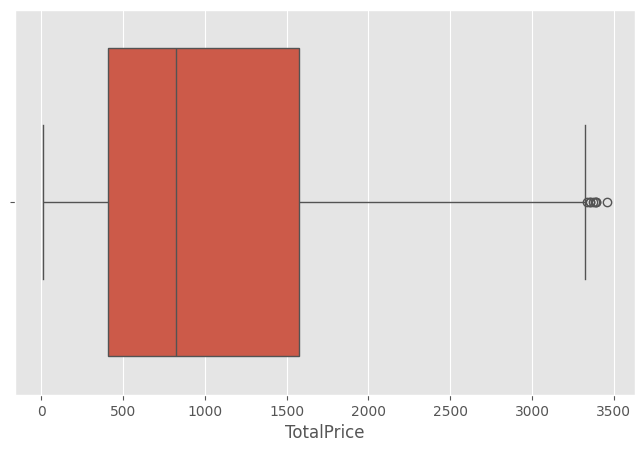

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalPrice"])
plt.show()

In [42]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["TotalPrice"] >= lower) &
        (df["TotalPrice"] <= upper)]

In [43]:
df["OrderMonth"] = df["Date"].dt.month_name()

In [44]:
df["OrderDay"] = df["Date"].dt.day_name()
df["AverageItemPrice"] = df["TotalPrice"] / df["Quantity"]
df["CouponUsed"] = df["CouponCode"].notna().astype(int)

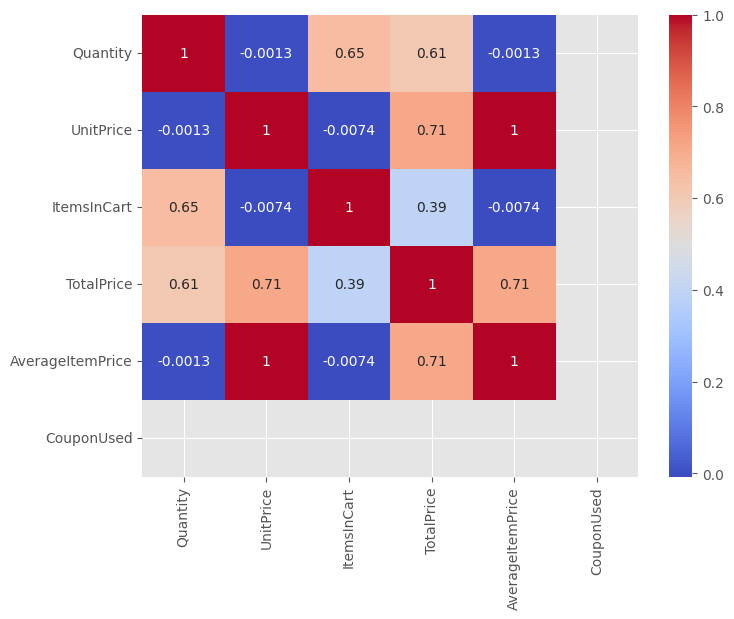

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

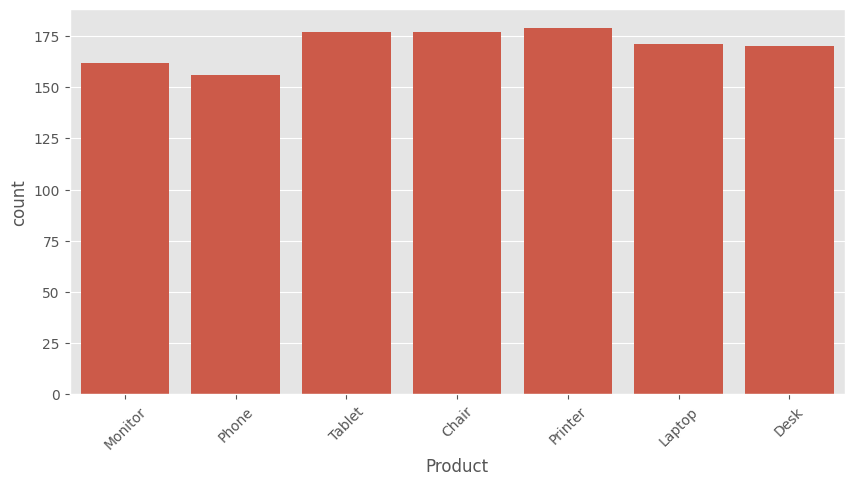

In [46]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="Product")

plt.xticks(rotation=45)

plt.show()

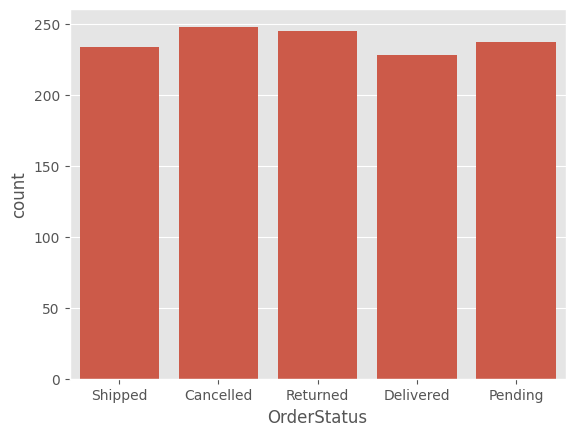

In [47]:
sns.countplot(data=df,
              x="OrderStatus")

plt.show()

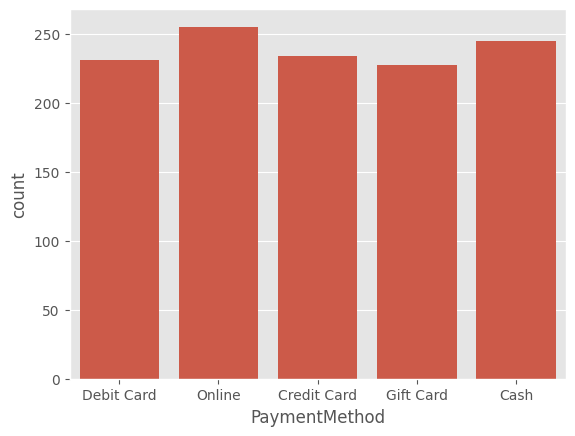

In [48]:
sns.countplot(data=df,
              x="PaymentMethod")

plt.show()

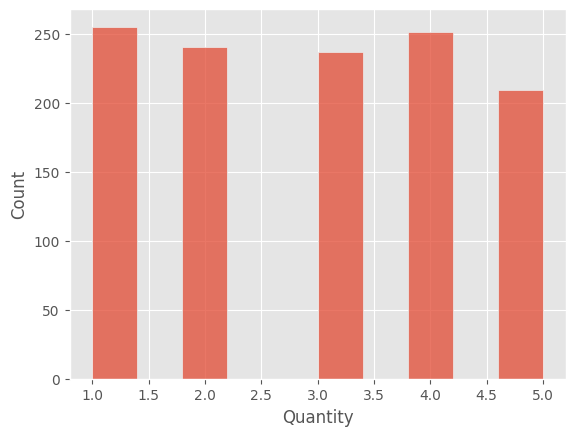

In [49]:
sns.histplot(df["Quantity"],
             bins=10)

plt.show()

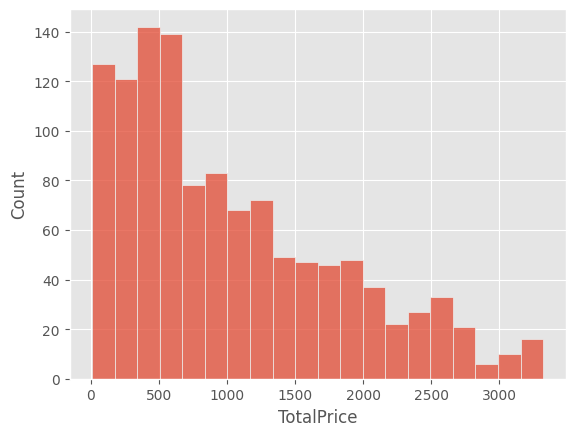

In [50]:
sns.histplot(df["TotalPrice"],
             bins=20)

plt.show()

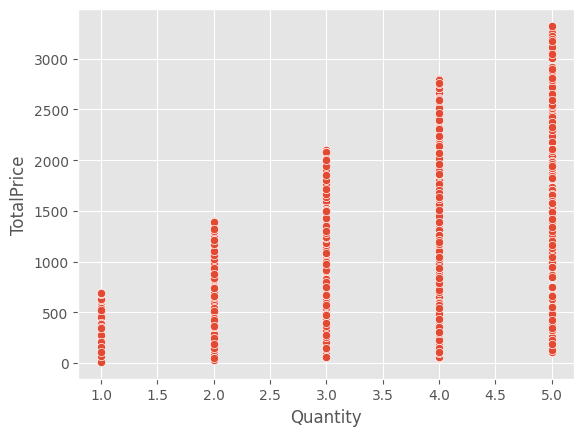

In [51]:
sns.scatterplot(data=df,
                x="Quantity",
                y="TotalPrice")

plt.show()

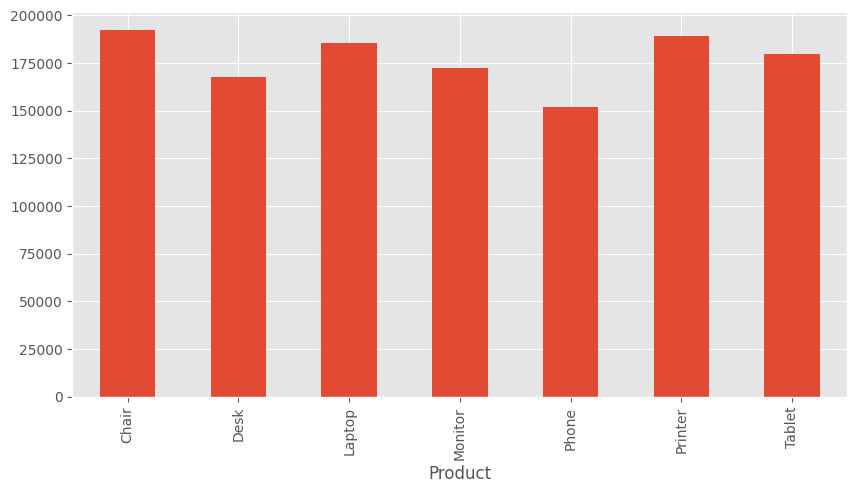

In [52]:
sales = df.groupby("Product")["TotalPrice"].sum()

sales.plot(kind="bar",
           figsize=(10,5))

plt.show()

In [53]:
df.to_excel("Cleaned_Dataset.xlsx",
            index=False)